# Exploratory Data Analysis

# # Titanic Analytics — Part A: Profiling, Cleaning, and Data Story


In [1]:
# 1. Load dataset and profile
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)  # offline fallback

df.info()
df.describe()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


(891, 15)

In [2]:
# 2. Missing value percentages
(df.isnull().sum() / len(df)) * 100


,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


## Strategy for missing values
- <5% → drop rows
- 5–30% → impute
- >30% → drop column or encode "missing"


<Axes: xlabel='age', ylabel='Count'>

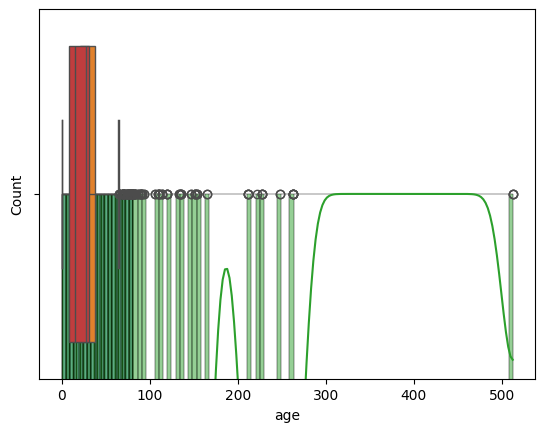

In [3]:
# 3. Univariate analysis: Age & Fare
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'], kde=True)
sns.boxplot(x=df['age'])

sns.histplot(df['fare'], kde=True)
sns.boxplot(x=df['fare'])


In [4]:
# Outlier counts using IQR
Q1, Q3 = df['fare'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = ((df['fare'] < Q1 - 1.5*IQR) | (df['fare'] > Q3 + 1.5*IQR)).sum()
outliers


np.int64(116)

## Skewness conclusion for Fare
- Compare mean, median, mode


In [5]:
# 4. Bivariate survival breakdowns
df.groupby("sex")["survived"].mean()
df.groupby("pclass")["survived"].mean()
df.groupby(["sex","pclass"])["survived"].mean()


sex     pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

<Axes: >

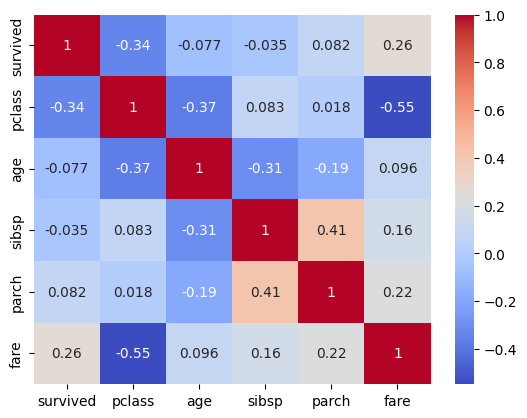

In [6]:
# Correlation matrix (6 specified columns)
cols = ["survived","pclass","age","sibsp","parch","fare"]
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")


 ## Interpretation of strongest correlations


<Axes: xlabel='sex', ylabel='pclass'>

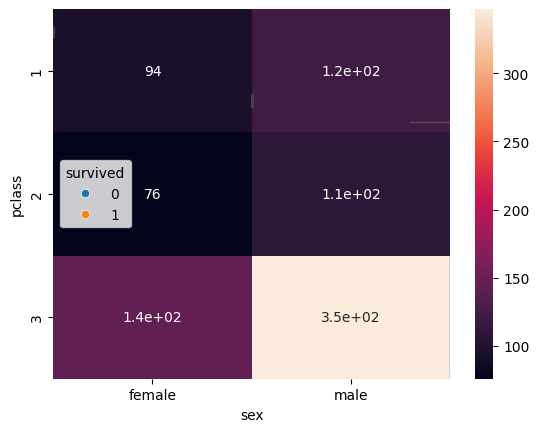

In [7]:
# 5. Multivariate data story — 4+ charts
sns.barplot(x="sex", y="survived", data=df)
sns.boxplot(x="pclass", y="age", data=df)
sns.scatterplot(x="age", y="fare", hue="survived", data=df)
sns.heatmap(pd.crosstab(df['pclass'], df['sex']), annot=True)


## Written interpretations (2–4 sentences each)


In [8]:
# 6. Standardization check
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age_scaled','fare_scaled']] = scaler.fit_transform(df[['age','fare']])
df[['age','fare']].describe(), df[['age_scaled','fare_scaled']].describe()


(              age        fare
 count  714.000000  891.000000
 mean    29.699118   32.204208
 std     14.526497   49.693429
 min      0.420000    0.000000
 25%     20.125000    7.910400
 50%     28.000000   14.454200
 75%     38.000000   31.000000
 max     80.000000  512.329200,
          age_scaled   fare_scaled
 count  7.140000e+02  8.910000e+02
 mean   2.388379e-16  3.987333e-18
 std    1.000701e+00  1.000562e+00
 min   -2.016979e+00 -6.484217e-01
 25%   -6.595416e-01 -4.891482e-01
 50%   -1.170488e-01 -3.573909e-01
 75%    5.718310e-01 -2.424635e-02
 max    3.465126e+00  9.667167e+00)